In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Tools loaded ✅")

Tools loaded ✅


In [7]:
url = "https://raw.githubusercontent.com/emmetgingerich/CSLUB-Datathon-find-your-cluster-Prithvi-Emmet/main/data/Credit_Card_Applications.csv"
df = pd.read_csv(url)

print("Loaded! Rows, columns:", df.shape)

Loaded! Rows, columns: (690, 16)


In [8]:
df.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


Split off the columns we DON'T cluster on

In [10]:
# CustomerID is just an ID number — meaningless for clustering, so drop it.
# Class is the bank's OLD approve/deny decision. We never cluster on it —
# instead we set it aside as our secret validation check for later.
y_validation = df["Class"]
features = df.drop(columns=["CustomerID", "Class"])

print("Columns we'll actually cluster on:")
print(list(features.columns))
print("\nFeature table shape:", features.shape)

Columns we'll actually cluster on:
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14']

Feature table shape: (690, 14)


Let the data tell us each column's type. See what type of data it is.

In [11]:
print("Unique values per feature:")
for col in features.columns:
    vals = sorted(features[col].unique())
    print(f"  {col:4s}  {features[col].nunique():3d} unique  ->  e.g. {vals[:6]}")

Unique values per feature:
  A1      2 unique  ->  e.g. [np.int64(0), np.int64(1)]
  A2    350 unique  ->  e.g. [np.float64(13.75), np.float64(15.17), np.float64(15.75), np.float64(15.83), np.float64(15.92), np.float64(16.0)]
  A3    215 unique  ->  e.g. [np.float64(0.0), np.float64(0.04), np.float64(0.08), np.float64(0.085), np.float64(0.125), np.float64(0.165)]
  A4      3 unique  ->  e.g. [np.int64(1), np.int64(2), np.int64(3)]
  A5     14 unique  ->  e.g. [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  A6      8 unique  ->  e.g. [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7)]
  A7    132 unique  ->  e.g. [np.float64(0.0), np.float64(0.04), np.float64(0.085), np.float64(0.125), np.float64(0.165), np.float64(0.21)]
  A8      2 unique  ->  e.g. [np.int64(0), np.int64(1)]
  A9      2 unique  ->  e.g. [np.int64(0), np.int64(1)]
  A10    23 unique  ->  e.g. [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np

Sort all 14 into three buckets

In [12]:
# already 0/1 — a yes/no, so leave them alone
binary_cols      = ["A1", "A8", "A9", "A11"]

# unordered category labels (the numbers are names, not amounts) — these need ONE-HOT encoding
categorical_cols = ["A4", "A5", "A6", "A12"]

# real quantities (age-like, money-like, counts) — these need SCALING
continuous_cols  = ["A2", "A3", "A7", "A10", "A13", "A14"]

# sanity check — did we account for all 14?
accounted = binary_cols + categorical_cols + continuous_cols
print("Columns sorted:", len(accounted), "(should be 14)")
print("Anything missed?", set(features.columns) - set(accounted))

Columns sorted: 14 (should be 14)
Anything missed? set()


**Phase 2 — Transform the data for clustering**
We have three buckets of columns, and each needs different handling before K-Means can use them. We process each bucket on its own, then stitch them into one final table. Each block below goes in its own Colab cell.

**Step 1 — One-hot encode the categories**
What we're doing: turning each categorical column (A4, A5, A6, A12) into a set of yes/no columns — one per category. Why: these numbers are just labels, not amounts. If we left A6 as 1–8, K-Means would wrongly think "category 8 is 7 bigger than category 1." One-hot encoding strips that fake ordering out so each category is just an independent flag.

In [13]:
# Turn each categorical column (A4, A5, A6, A12) into yes/no columns —
# one new column per category. astype(str) makes pandas treat them as
# labels, not numbers.
cat_encoded = pd.get_dummies(features[categorical_cols].astype(str)).astype(int)

print("One-hot columns created:", cat_encoded.shape[1])
print(cat_encoded.columns.tolist())
cat_encoded.head()

One-hot columns created: 28
['A4_1', 'A4_2', 'A4_3', 'A5_1', 'A5_10', 'A5_11', 'A5_12', 'A5_13', 'A5_14', 'A5_2', 'A5_3', 'A5_4', 'A5_5', 'A5_6', 'A5_7', 'A5_8', 'A5_9', 'A6_1', 'A6_2', 'A6_3', 'A6_4', 'A6_5', 'A6_7', 'A6_8', 'A6_9', 'A12_1', 'A12_2', 'A12_3']


,A4_1,A4_2,A4_3,A5_1,A5_10,A5_11,A5_12,A5_13,A5_14,A5_2,...,A6_2,A6_3,A6_4,A6_5,A6_7,A6_8,A6_9,A12_1,A12_2,A12_3
0,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
3,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


**Step 2 — Scale the continuous columns**
What we're doing: rescaling the real quantities (A2, A3, A7, A10, A13, A14) so they all sit on the same numeric footing — mean ≈ 0, spread ≈ 1. Why: K-Means measures distance, and A14 runs to 100,000 while A2 maxes at 80. Without scaling, A14's giant numbers would drown out every other feature and clusters would form on income alone. Scaling gives every quantity an equal vote.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cont_scaled = pd.DataFrame(
    scaler.fit_transform(features[continuous_cols]),
    columns=continuous_cols,
    index=features.index
)

print("After scaling (mean should be ~0, std ~1):")
print(cont_scaled.describe().round(2))

After scaling (mean should be ~0, std ~1):
           A2      A3      A7     A10     A13     A14
count  690.00  690.00  690.00  690.00  690.00  690.00
mean     0.00    0.00    0.00   -0.00    0.00    0.00
std      1.00    1.00    1.00    1.00    1.00    1.00
min     -1.50   -0.96   -0.66   -0.49   -1.07   -0.20
25%     -0.75   -0.76   -0.62   -0.49   -0.60   -0.20
50%     -0.25   -0.40   -0.37   -0.49   -0.14   -0.19
75%      0.52    0.49    0.12    0.12    0.51   -0.12
max      4.11    4.67    7.86   13.29   10.56   19.01


**Step 3 — Stitch the final clustering table together**
What we're doing: combining all three buckets — untouched binary flags, scaled quantities, and one-hot categories — into one matrix X. Why: this is the single prepared table K-Means actually sees, with every value now either a 0/1 flag or a scaled number, all comparable.

In [15]:
# binary cols stay as-is, scaled continuous + one-hot categorical join them
X = pd.concat([
    features[binary_cols].astype(int),   # 4 yes/no flags, untouched
    cont_scaled,                          # 6 scaled quantities
    cat_encoded                           # 28 one-hot category columns
], axis=1)

print("Final clustering matrix shape:", X.shape)
X.head()

Final clustering matrix shape: (690, 38)


,A1,A8,A9,A11,A2,A3,A7,A10,A13,A14,...,A6_2,A6_3,A6_4,A6_5,A6_7,A6_8,A6_9,A12_1,A12_2,A12_3
0,1,0,0,1,-0.801052,1.347111,-0.190906,-0.493887,-0.488358,0.037380,...,0,0,1,0,0,0,0,0,1,0
1,0,0,0,0,-0.751240,0.450548,-0.615536,-0.493887,-0.139591,-0.195413,...,0,0,1,0,0,0,0,0,1,0
2,0,0,0,1,-0.167856,-0.604823,-0.291083,-0.493887,0.557943,-0.195413,...,0,0,1,0,0,0,0,0,1,0
3,0,1,1,1,-0.835667,1.355152,-0.664877,1.769760,-1.069637,-0.195413,...,0,1,0,0,0,0,0,0,1,0
4,1,1,1,0,-0.962306,0.685745,-0.078768,2.387119,-0.720870,-0.165066,...,0,0,1,0,0,0,0,0,1,0


**Phase 3 — the payoff**
We answer "how many types of applicant are there?" with evidence, then run K-Means and finally see the groups. Four cells.

**Step 1 — Find the right number of clusters (elbow + silhouette)**
What we're doing: trying every k from 2 to 10 and scoring each one two different ways, so we pick the number of clusters from data instead of guessing. Why: nobody told us whether there are 3 types of applicant or 7 — this is how we discover it, and it's a guaranteed Q&A question ("why k clusters?").

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []        # "how tight are the clusters" — lower is tighter
silhouettes = []     # "how cleanly separated" — higher is better (max 1.0)
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    print(f"k={k}:  inertia={km.inertia_:8.1f}   silhouette={silhouettes[-1]:.3f}")

k=2:  inertia=  5327.9   silhouette=0.297
k=3:  inertia=  4941.9   silhouette=0.132
k=4:  inertia=  4564.6   silhouette=0.120
k=5:  inertia=  4169.7   silhouette=0.120
k=6:  inertia=  3967.8   silhouette=0.111
k=7:  inertia=  3743.1   silhouette=0.119
k=8:  inertia=  3601.2   silhouette=0.096
k=9:  inertia=  3442.1   silhouette=0.096
k=10:  inertia=  3322.6   silhouette=0.101


**Step 2 — Plot both so the choice is visual**
What we're doing: drawing the two scores side by side. Why: the elbow is far easier to see than to read off numbers, and a clean plot is exactly the kind of figure that goes in your Model Report.

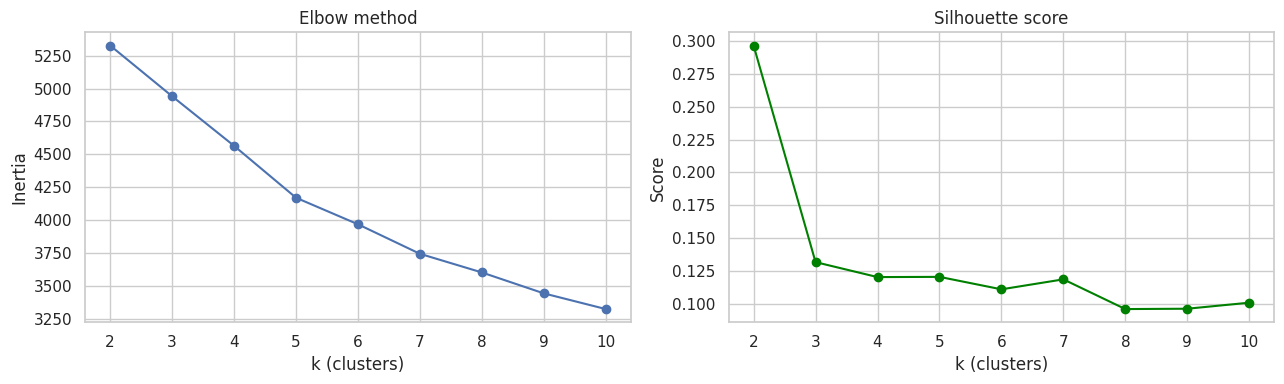

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(k_range), inertias, "o-")
ax1.set_title("Elbow method"); ax1.set_xlabel("k (clusters)"); ax1.set_ylabel("Inertia")

ax2.plot(list(k_range), silhouettes, "o-", color="green")
ax2.set_title("Silhouette score"); ax2.set_xlabel("k (clusters)"); ax2.set_ylabel("Score")

plt.tight_layout(); plt.show()

**Run K-Means — both the finding (k=2) and the product (k=4)**
What we're doing: fitting two separate K-Means models. The k=2 model is the statistically-best split we'll feature in the Model Report; the k=4 model is the richer grouping the app actually uses. Why: this directly enacts the trade-off we decided on — let the data lead in the report, serve the user better in the product — and having both objects in hand lets us profile and compare them in Phase 4.

In [18]:
# k=2 — the statistically strongest split (our REPORT headline finding)
kmeans_report = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_k2 = kmeans_report.fit_predict(X)

# k=4 — the richer grouping the PRODUCT uses
kmeans_product = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_k4 = kmeans_product.fit_predict(X)

# attach BOTH label sets to the readable original data for profiling later
df_clustered = features.copy()
df_clustered["Cluster_k2"] = labels_k2
df_clustered["Cluster_k4"] = labels_k4

print("k=2 (report) sizes:")
print(df_clustered["Cluster_k2"].value_counts().sort_index())
print("\nk=4 (product) sizes:")
print(df_clustered["Cluster_k4"].value_counts().sort_index())

k=2 (report) sizes:
Cluster_k2
0    567
1    123
Name: count, dtype: int64

k=4 (product) sizes:
Cluster_k4
0    450
1     87
2      1
3    152
Name: count, dtype: int64


**See the clusters in 2D (PCA), colored by the product's k=4 groups**
What we're doing: using PCA to flatten the 38 columns to 2 so we can plot every applicant as a dot, colored by their k=4 cluster. Why: this is the single most convincing visual in your demo — it lets anyone see whether the groups are real, separated regions or one smeared blob. We color by k=4 because that's what the app shows users.

Variance captured by the 2 components: [0.228 0.12 ]
Total captured: 0.348


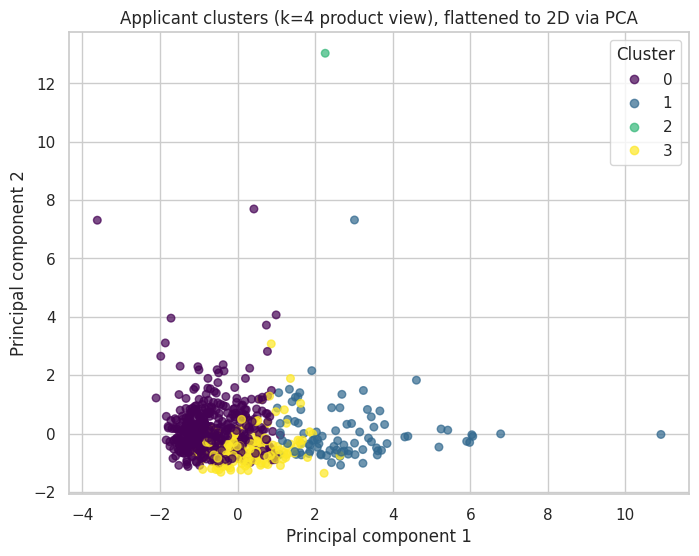

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels_k4, cmap="viridis", s=30, alpha=0.7)
plt.title("Applicant clusters (k=4 product view), flattened to 2D via PCA")
plt.xlabel("Principal component 1"); plt.ylabel("Principal component 2")
plt.legend(*scatter.legend_elements(), title="Cluster")

# how much of the real spread these 2 components actually capture
print("Variance captured by the 2 components:", pca.explained_variance_ratio_.round(3))
print("Total captured:", pca.explained_variance_ratio_.sum().round(3))

## A problem appears: k=4 produced a cluster of one

Our k=4 run put a single applicant in their own cluster (Cluster 2, size = 1).
A cluster of one isn't a "type" of person — it's a sign that one extreme outlier
is so far from everyone else that K-Means spent a whole centroid on them.
We suspect this is caused by heavy right-skew in our money columns, which K-Means
(a distance-based method) is very sensitive to. Let's check.

**What we're doing:** measuring the skew of each continuous column and finding the extreme applicant. Why: this proves the outlier problem with numbers instead of a hunch.

In [22]:
print("Skewness (0 = symmetric, >1 = heavy right tail):")
print(features[continuous_cols].skew().round(2))

print("\nThe most extreme applicant on A14:")
print(features.loc[[features['A14'].idxmax()], continuous_cols])

Skewness (0 = symmetric, >1 = heavy right tail):
A2      1.16
A3      1.49
A7      2.89
A10     5.15
A13     2.75
A14    13.14
dtype: float64

The most extreme applicant on A14:
       A2    A3   A7  A10  A13     A14
500  17.5  22.0  0.0    0  450  100001


## The fix: log-transform the skewed columns

A log transform compresses long right tails — the distance from 450 to 100,001
shrinks dramatically, so no single applicant can dominate the clustering anymore.
We apply np.log1p() (log of 1+x, which safely handles zeros) to every continuous
column with skew > 1, leaving A2 (age) in its natural units since it's only mildly
skewed and we want it interpretable. Then we re-scale and rebuild our feature matrix
as X_log, and re-run everything on the corrected data.

In [23]:
log_cols = ["A3", "A7", "A10", "A13", "A14"]

features_logged = features.copy()
features_logged[log_cols] = np.log1p(features_logged[log_cols])

scaler_log = StandardScaler()
cont_scaled_log = pd.DataFrame(
    scaler_log.fit_transform(features_logged[continuous_cols]),
    columns=continuous_cols, index=features.index
)

X_log = pd.concat([
    features[binary_cols].astype(int),
    cont_scaled_log,
    cat_encoded
], axis=1)

print("Skew after logging:")
print(features_logged[continuous_cols].skew().round(2))
print("\nX_log shape:", X_log.shape)

Skew after logging:
A2     1.16
A3     0.17
A7     0.82
A10    1.05
A13   -1.30
A14    0.60
dtype: float64

X_log shape: (690, 38)


re-run k-selection on the corrected data:

Re-running k selection on the LOG-TRANSFORMED data:
k=2:  inertia=  5134.2   silhouette=0.186
k=3:  inertia=  4678.3   silhouette=0.148
k=4:  inertia=  4343.4   silhouette=0.158
k=5:  inertia=  4067.9   silhouette=0.123
k=6:  inertia=  3868.5   silhouette=0.125
k=7:  inertia=  3725.0   silhouette=0.110
k=8:  inertia=  3608.0   silhouette=0.110
k=9:  inertia=  3510.2   silhouette=0.100
k=10:  inertia=  3417.6   silhouette=0.101


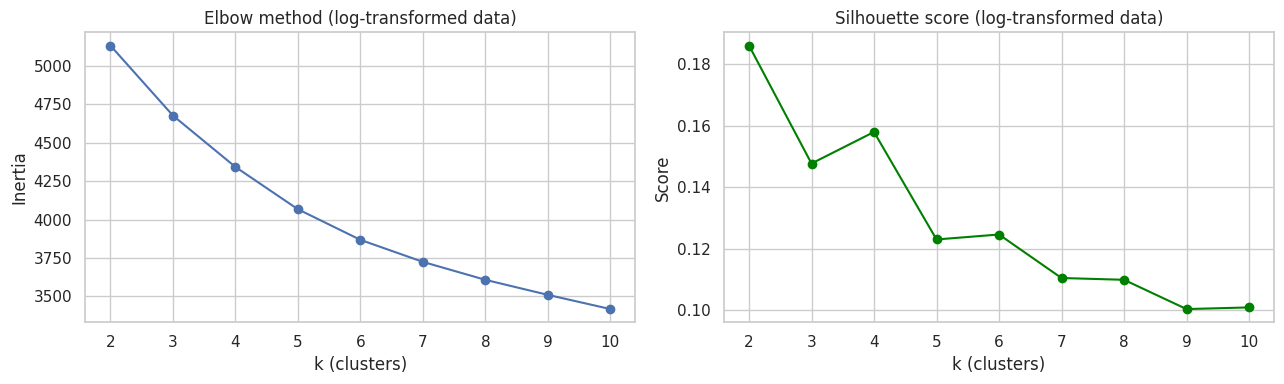

In [25]:
print("Re-running k selection on the LOG-TRANSFORMED data:")

ks = range(2, 11)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_log)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_log, lbl))
    print(f"k={k}:  inertia={km.inertia_:8.1f}   silhouette={silhouettes[-1]:.3f}")

# now plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(ks), inertias, "o-")
ax1.set_title("Elbow method (log-transformed data)")
ax1.set_xlabel("k (clusters)"); ax1.set_ylabel("Inertia")

ax2.plot(list(ks), silhouettes, "o-", color="green")
ax2.set_title("Silhouette score (log-transformed data)")
ax2.set_xlabel("k (clusters)"); ax2.set_ylabel("Score")

plt.tight_layout()
plt.show()

**What we're doing: fitting k=2 (report headline) and k=3 or 4 (product) on X_log.** Why: the real test — if logging worked, k=3 or 4 has three real groups and no cluster of one.

In [27]:
kmeans_report = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_k3     = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_k4     = KMeans(n_clusters=4, random_state=42, n_init=10)

labels_k2 = kmeans_report.fit_predict(X_log)
labels_k3 = kmeans_k3.fit_predict(X_log)
labels_k4 = kmeans_k4.fit_predict(X_log)

df_clustered = features.copy()
df_clustered["Cluster_k2"] = labels_k2
df_clustered["Cluster_k3"] = labels_k3
df_clustered["Cluster_k4"] = labels_k4

for k, lbl in [(2, labels_k2), (3, labels_k3), (4, labels_k4)]:
    sizes = df_clustered[f"Cluster_k{k}"].value_counts().sort_index().tolist()
    print(f"k={k}:  silhouette={silhouette_score(X_log, lbl):.3f}   sizes={sizes}")

k=2:  silhouette=0.186   sizes=[453, 237]
k=3:  silhouette=0.148   sizes=[119, 192, 379]
k=4:  silhouette=0.158   sizes=[364, 176, 82, 68]


**What we're doing: plotting the PCA scatter colored by your final k=4 product clustering.** Why: this is the figure that shows the four groups are real, separated regions — your key demo visual and the proof behind the "we chose k=4" decision.

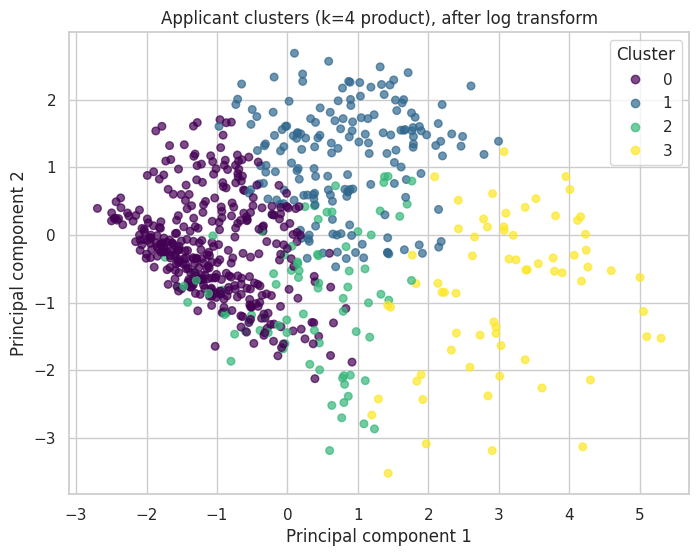

Variance captured: [0.256 0.131]


In [28]:
product_labels = labels_k4   # k=4 is our product choice

coords_log = PCA(n_components=2, random_state=42).fit_transform(X_log)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords_log[:, 0], coords_log[:, 1],
                      c=product_labels, cmap="viridis", s=30, alpha=0.7)
plt.title("Applicant clusters (k=4 product), after log transform")
plt.xlabel("Principal component 1"); plt.ylabel("Principal component 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

print("Variance captured:", PCA(n_components=2).fit(X_log).explained_variance_ratio_.round(3))

In [29]:
kmeans_final = kmeans_k4   # this + scaler_log get saved as the model artifact

## Phase 4 — Who is in each cluster?

Clusters are only useful if we can describe them. For each of our 4 groups we
compute the "typical" applicant (median values, in original units so they're
human-readable), then we run a validation check: we peek at the historical
approval rate (Class) per cluster. The model never used Class — so if the
clusters separate cleanly by approval, that's evidence they capture something real.

## Build the profile table
**What we're doing: attaching the cluster labels and Class back to the readable original data, then computing the median applicant per cluster.** Why: medians in original units are what we'll show users and judges — "the typical person in your group" — instead of meaningless scaled numbers.

In [30]:
profile = features.copy()
profile["Cluster"] = labels_k4
profile["Class"] = df["Class"]

print("Typical applicant per cluster (median, original units):")
print(profile.groupby("Cluster")[continuous_cols].median().round(2))

print("\nBinary flags — share that are 1:")
print(profile.groupby("Cluster")[binary_cols].mean().round(2))

Typical applicant per cluster (median, original units):
            A2     A3    A7  A10    A13    A14
Cluster                                       
0        26.79   2.00  0.50  0.0  200.0    1.0
1        27.71   3.00  1.75  4.0  190.5  452.0
2        29.58   3.25  0.62  0.0    0.0    2.5
3        52.66  10.25  6.40  7.0    0.0  360.0

Binary flags — share that are 1:
           A1    A8    A9   A11
Cluster                        
0        0.69  0.30  0.12  0.44
1        0.69  0.86  0.96  0.55
2        0.63  0.44  0.26  0.37
3        0.65  0.96  0.90  0.44


## The validation check

**What we're doing: computing the historical approval rate within each cluster.** Why: this is the proof. The clustering was blind to Class; if approval still varies sharply by cluster, the groups are meaningful, not noise.

In [31]:
print("Overall approval rate:", round(df["Class"].mean(), 3))
print("\nApproval rate by cluster (validation):")
print(profile.groupby("Cluster")["Class"].agg(["mean", "count"]).round(3))

Overall approval rate: 0.445

Approval rate by cluster (validation):
          mean  count
Cluster              
0        0.201    364
1        0.795    176
2        0.402     82
3        0.897     68


## Make it a chart

**What we're doing: plotting approval rate per cluster as a bar chart with the overall average as a reference line.** Why: "20% vs 90%" lands far harder as a visual than a table — this is a key demo slide.

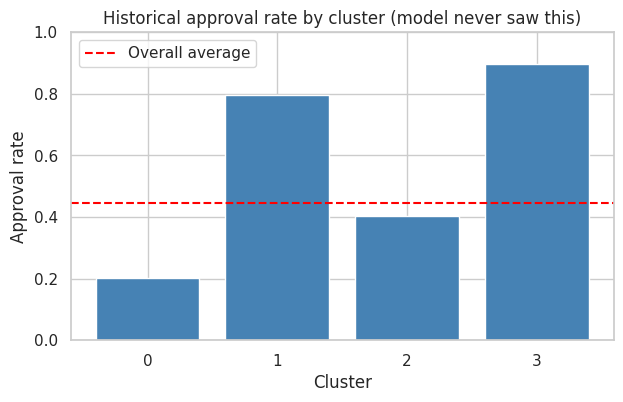

In [32]:
rates = profile.groupby("Cluster")["Class"].mean()

plt.figure(figsize=(7, 4))
plt.bar(rates.index.astype(str), rates.values, color="steelblue")
plt.axhline(df["Class"].mean(), color="red", linestyle="--", label="Overall average")
plt.title("Historical approval rate by cluster (model never saw this)")
plt.xlabel("Cluster"); plt.ylabel("Approval rate"); plt.ylim(0, 1); plt.legend()
plt.show()

In [ ]:
# ── Phase 4 Cont — What does your cluster mean for YOU? ──────────────────────────
#
# This cell reads directly from objects already in memory:
#   profile, labels_k4, cluster_names, continuous_cols, binary_cols
# No changes needed to any earlier cell.

cluster_insights = {
    0: {
        "headline": "You're at the start of your financial story — and that's okay.",
        "what_it_means": (
            "Most people in your cluster are young, early in their careers, and haven't "
            "had much time to build a credit track record yet. Your credit balance is "
            "already showing up, which means you're engaging with credit — but employment "
            "tenure and income are still thin. Historically, only about 1 in 5 applicants "
            "in this group were approved, not because they're risky people, but because "
            "the file just doesn't have enough history for lenders to feel confident yet."
        ),
        "what_moves_the_needle": [
            "Stay employed — even 1–2 more years of continuous employment meaningfully "
            "separates this cluster from the next one up.",
            "Keep your credit balance low relative to your limit. The typical person "
            "who moves up carries a balance around $190, not zero and not maxed out.",
            "Avoid any defaults at all costs. Only 12% of this cluster has a clean "
            "default record — that's the single biggest thing holding the group back.",
        ],
        "maintain": None,
    },
    1: {
        "headline": "You're in a strong position — your file is active and your record is clean.",
        "what_it_means": (
            "People in your cluster are employed, have a solid employment history of "
            "around 3 years, carry a modest credit balance (~$190–450), and almost "
            "universally have no prior defaults. That combination earns an 80% historical "
            "approval rate. You're not at the top yet — that requires significantly more "
            "tenure and stability — but you're well above average."
        ),
        "what_moves_the_needle": [
            "Time is your main lever here. The 'Seasoned profile' cluster looks almost "
            "identical to yours except they're 25 years older with 10 years of employment. "
            "Consistency over time is what separates the two.",
            "Keep your debt load manageable. The typical person in your group carries "
            "about $4K in debt — not zero, but not overwhelming relative to income.",
        ],
        "maintain": (
            "Don't let your default record slip. 96% of your cluster has a clean history — "
            "that's the foundation everything else is built on. Protect it."
        ),
    },
    2: {
        "headline": "Your file exists, but lenders can't quite read it yet.",
        "what_it_means": (
            "This is the most mixed cluster in the dataset. People here are slightly older "
            "than average, but employment is inconsistent — only about 44% are currently "
            "employed — and income is very low. Credit balance sits at zero, which sounds "
            "good but can actually signal that lenders don't have enough activity to judge "
            "you on. The 40% approval rate reflects that ambiguity: you're not a clear "
            "no, but you're not a clear yes either."
        ),
        "what_moves_the_needle": [
            "Employment is the most urgent lever. Getting to and staying employed "
            "consistently is what separates this cluster from Cluster 1.",
            "Start building a credit history deliberately — a small balance you pay off "
            "regularly gives lenders something to evaluate. Zero activity is harder to "
            "approve than modest, clean activity.",
            "Avoid defaults. Only 26% of this cluster has a clean record, which is "
            "dragging the group's approval rate down significantly.",
        ],
        "maintain": None,
    },
    3: {
        "headline": "You've built exactly the kind of profile lenders trust most.",
        "what_it_means": (
            "Your cluster has the highest approval rate in the dataset at nearly 90%. "
            "The defining features are time and consistency — a median age of 53, over "
            "10 years of employment, 6+ years at the same address, and an almost "
            "universally clean default record. Lenders read long tenure as low risk, "
            "and your cluster is the proof. This isn't about income — your median income "
            "is actually lower than Cluster 1 — it's about the story that decades of "
            "stability tells."
        ),
        "what_moves_the_needle": None,
        "maintain": (
            "Protect your default record above everything else — 90% of your cluster "
            "has never defaulted, and that's the bedrock of your standing. Beyond that, "
            "maintaining employment and residential stability is what keeps you here. "
            "You've already done the hard work."
        ),
    },
}

# ── Print the insight for the user's cluster ─────────────────────────────────

# In the app, replace `user_cluster` with however you identify the user's cluster.
# Here we demonstrate by looping all four so you can see every output.

print("=" * 65)
print("  CLUSTER INSIGHTS")
print("=" * 65)

for cluster_id, name in cluster_names.items():
    insight = cluster_insights[cluster_id]
    approval = profile.groupby("Cluster")["Class"].mean()[cluster_id]

    print(f"\n{'─'*65}")
    print(f"  Cluster {cluster_id}: {name}  |  Historical approval rate: {approval:.0%}")
    print(f"{'─'*65}")
    print(f"\n  {insight['headline']}\n")
    print(f"  What this means:\n  {insight['what_it_means']}\n")

    if insight["what_moves_the_needle"]:
        print("  What moves the needle:")
        for tip in insight["what_moves_the_needle"]:
            print(f"    → {tip}")
        print()

    if insight["maintain"]:
        print(f"  How to stay here:\n    → {insight['maintain']}\n")

print("=" * 65)

## Phase 5 — Save the model for the app

The app must preprocess a new applicant EXACTLY like we did here: log the same
columns, scale with the same fitted scaler, one-hot encode, and align to the same
38 columns. So we save not just the K-Means model but the whole recipe — scaler,
column lists, cluster names, and profiles — in one bundle the app can load.

## Build and save the bundle:

**What we're doing: packaging the model, the scaler, all the column definitions, the cluster names, and the display profiles into one dictionary, then writing it to cluster_model.joblib.** Why: one self-contained file means the app loads a single thing and has everything — no risk of the app's preprocessing drifting from the notebook's.

In [33]:
import joblib

feature_columns = list(X_log.columns)   # the exact 38-column layout

model_bundle = {
    "kmeans": kmeans_final,
    "scaler": scaler_log,
    "binary_cols": binary_cols,
    "categorical_cols": categorical_cols,
    "continuous_cols": continuous_cols,
    "log_cols": log_cols,
    "feature_columns": feature_columns,
    "cluster_names": {
        0: "Building from scratch",
        2: "Quiet file",
        1: "Active & established",
        3: "Seasoned profile",
    },
    "cluster_profiles": profile.groupby("Cluster")[continuous_cols].median().round(2).to_dict("index"),
    "approval_rates": profile.groupby("Cluster")["Class"].mean().round(3).to_dict(),
}

joblib.dump(model_bundle, "cluster_model.joblib")
print("Saved cluster_model.joblib ✅")
print("Contains:", list(model_bundle.keys()))

Saved cluster_model.joblib ✅
Contains: ['kmeans', 'scaler', 'binary_cols', 'categorical_cols', 'continuous_cols', 'log_cols', 'feature_columns', 'cluster_names', 'cluster_profiles', 'approval_rates']


## Download it to your laptop:

**What we're doing: pulling the saved file out of Colab onto your computer.** Why: Colab's filesystem is temporary — we need the file in your GitHub repo so the app can use it.

In [34]:
from google.colab import files
files.download("cluster_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>